## LA Superfund Site Demographic Analysis

#### Author: Jen Bays
#### Date: 08April2026

#### Summary
This script will loop through my clipped buffer files and calculate total estimated population from 1970 to 2020

In [1]:
import pandas as pd
import os
import geopandas as gpd
import re

buffer_results_dir = r"C:\Users\bays0022\Desktop\GIS_Data\Census\LA_County_Subsets\Superfund_Buffer_Analysis"
summary_stats = []

print("Analyzing demographic shifts (with numeric conversion)...")

for f in sorted(os.listdir(buffer_results_dir)):
    if f.endswith(".shp"):
        gdf = gpd.read_file(os.path.join(buffer_results_dir, f))
        
        year_full = re.search(r'\d{4}', f).group(0)
        yr = year_full[-2:] 
        
        #  Convert columns to numeric before multiplying ---
        # Use errors='coerce' to turn any non-numeric junk into 'NaN'
        pop_col = pd.to_numeric(gdf[f'TotPop_{yr}'], errors='coerce').fillna(0)
        white_col = pd.to_numeric(gdf[f'White_{yr}'], errors='coerce').fillna(0)
        black_col = pd.to_numeric(gdf[f'Black_{yr}'], errors='coerce').fillna(0)
        weight = pd.to_numeric(gdf['weight'], errors='coerce').fillna(0)

        # Multiplication and summation with numeric safety checks
        total_pop = (pop_col * weight).sum()
        white_pop = (white_col * weight).sum()
        black_pop = (black_col * weight).sum()
        
        # Add income/youth with the same numeric safety check
        low_inc_name = f'Inc_Lt10k_'
        low_inc_val = 0
        if low_inc_name in gdf.columns:
            low_inc_col = pd.to_numeric(gdf[low_inc_name], errors='coerce').fillna(0)
            low_inc_val = (low_inc_col * weight).sum()

        summary_stats.append({
            'Year': year_full,
            'Est_Total_Pop': int(total_pop),
            'White_%': round((white_pop / total_pop) * 100, 1) if total_pop > 0 else 0,
            'Black_%': round((black_pop / total_pop) * 100, 1) if total_pop > 0 else 0,
            'Low_Inc_%': round((low_inc_val / total_pop) * 100, 1) if total_pop > 0 else 0
        })

df_trends = pd.DataFrame(summary_stats).sort_values('Year')

print("\n--- Final Demographic Timeline for Superfund Buffer ---")
print(df_trends.to_string(index=False))

Analyzing demographic shifts (with numeric conversion)...

--- Final Demographic Timeline for Superfund Buffer ---
Year  Est_Total_Pop  White_%  Black_%  Low_Inc_%
1970         261042     93.2      3.2       12.0
1980         271872     72.3      4.2        4.8
1990         323790     51.5      4.5        2.0
2000         343769     46.1      4.0        0.0
2020         334798     27.0      3.0        0.0


In [2]:

buffer_results_dir = r"C:\Users\bays0022\Desktop\GIS_Data\Census\LA_County_Subsets\Superfund_Buffer_Analysis"
summary_stats = []

print(" Analyzing Income and Demographic shifts...")

for f in sorted(os.listdir(buffer_results_dir)):
    if f.endswith(".shp"):
        gdf = gpd.read_file(os.path.join(buffer_results_dir, f))
        
        year_full = re.search(r'\d{4}', f).group(0)
        yr = year_full[-2:] 
        
        # Helper to safely sum weighted columns
        def get_weighted_sum(df, col_name):
            if col_name in df.columns:
                series = pd.to_numeric(df[col_name], errors='coerce').fillna(0)
                weight = pd.to_numeric(df['weight'], errors='coerce').fillna(0)
                return (series * weight).sum()
            return 0

        # Totals
        total_pop = get_weighted_sum(gdf, f'TotPop_{yr}')
        
        # Race
        white_pop = get_weighted_sum(gdf, f'White_{yr}')
        black_pop = get_weighted_sum(gdf, f'Black_{yr}')
        
        # Income - Comparing the bottom and top brackets provided in the codebook
        # Note: 1970/80/90 labels might vary slightly; we use the names from our translation map
        low_inc = get_weighted_sum(gdf, 'Inc_Lt10k_')
        high_inc = get_weighted_sum(gdf, 'Inc_Gt50k_')

        summary_stats.append({
            'Year': year_full,
            'Total_Pop': int(total_pop),
            'White_%': round((white_pop / total_pop) * 100, 1) if total_pop > 0 else 0,
            'Black_%': round((black_pop / total_pop) * 100, 1) if total_pop > 0 else 0,
            'Low_Inc_%': round((low_inc / total_pop) * 100, 1) if total_pop > 0 else 0,
            'High_Inc_%': round((high_inc / total_pop) * 100, 1) if total_pop > 0 else 0
        })

df_trends = pd.DataFrame(summary_stats).sort_values('Year')

print("\n--- Socioeconomic Timeline for Superfund Buffer ---")
print(df_trends.to_string(index=False))

 Analyzing Income and Demographic shifts...

--- Socioeconomic Timeline for Superfund Buffer ---
Year  Total_Pop  White_%  Black_%  Low_Inc_%  High_Inc_%
1970     261042     93.2      3.2       12.0         0.2
1980     271872     72.3      4.2        4.8         1.2
1990     323790     51.5      4.5        2.0         6.9
2000     343769     46.1      4.0        0.0         0.0
2020     334798     27.0      3.0        0.0         0.0


Demographic Growth

In [3]:
# Calculate the percentage point change between decades
df_trends['Pop_Change'] = df_trends['Total_Pop'].diff()
df_trends['White_Shift'] = df_trends['White_%'].diff()
df_trends['Low_Inc_Shift'] = df_trends['Low_Inc_%'].diff()

print("Decadal Shifts (Change from previous decade):")
print(df_trends[['Year', 'Pop_Change', 'White_Shift', 'Low_Inc_Shift']])

Decadal Shifts (Change from previous decade):
   Year  Pop_Change  White_Shift  Low_Inc_Shift
0  1970         NaN          NaN            NaN
1  1980     10830.0        -20.9           -7.2
2  1990     51918.0        -20.8           -2.8
3  2000     19979.0         -5.4           -2.0
4  2020     -8971.0        -19.1            0.0


Correlation Matrix


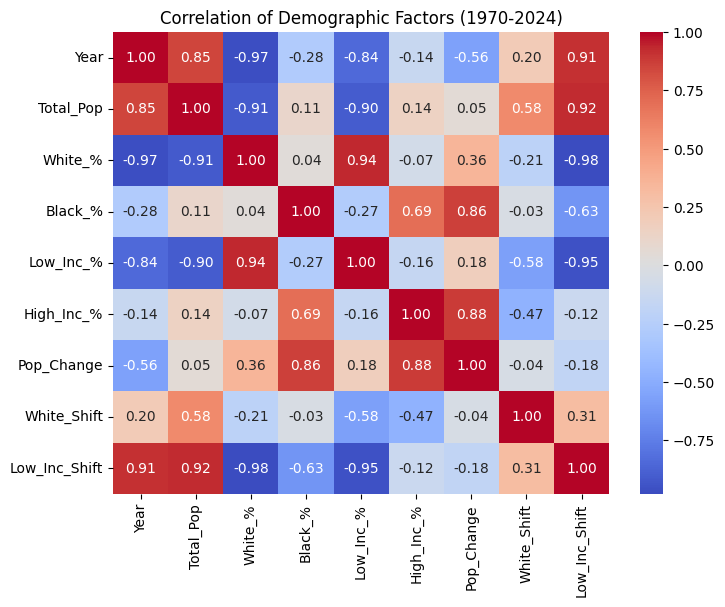

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation between columns
plt.figure(figsize=(8, 6))
sns.heatmap(df_trends.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation of Demographic Factors (1970-2024)")
plt.show()

Tipping Point

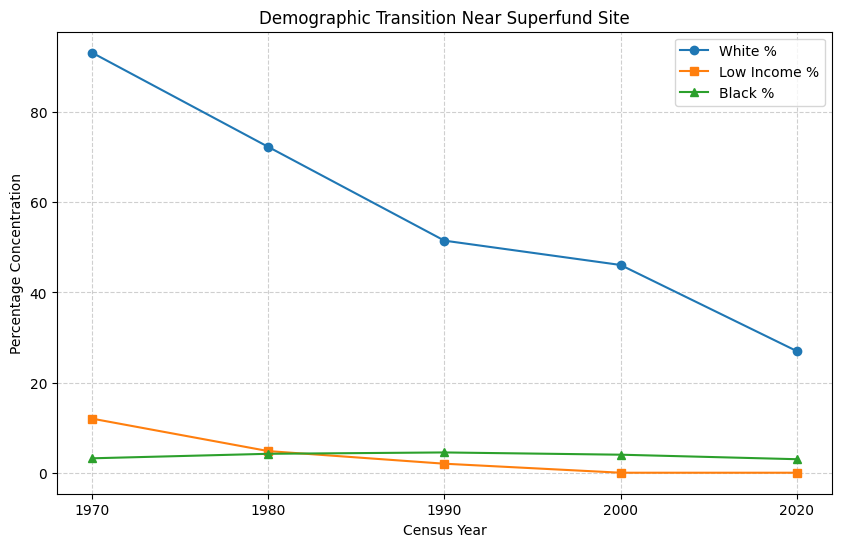

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_trends['Year'], df_trends['White_%'], label='White %', marker='o')
plt.plot(df_trends['Year'], df_trends['Low_Inc_%'], label='Low Income %', marker='s')
plt.plot(df_trends['Year'], df_trends['Black_%'], label='Black %', marker='^')

plt.title("Demographic Transition Near Superfund Site")
plt.xlabel("Census Year")
plt.ylabel("Percentage Concentration")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

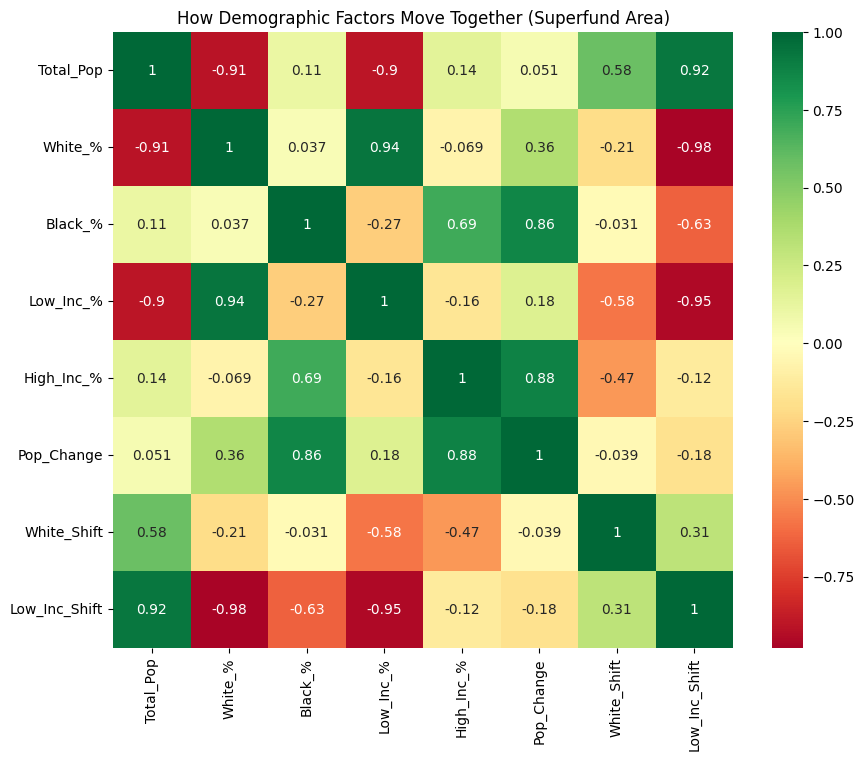

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# We only want to correlate the numeric columns
# Drop 'Year' from the correlation if you want to see how the other factors interact
numeric_df = df_trends.drop(columns=['Year'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', center=0)
plt.title("How Demographic Factors Move Together (Superfund Area)")
plt.show()

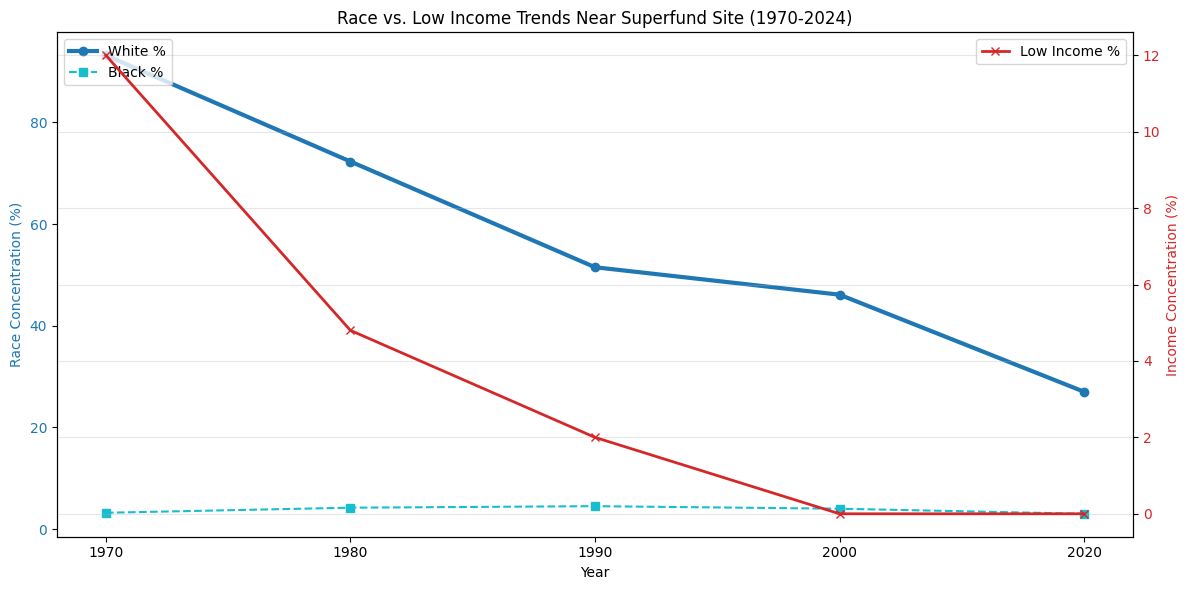

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Race on the left axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Race Concentration (%)', color='tab:blue')
ax1.plot(df_trends['Year'], df_trends['White_%'], label='White %', marker='o', color='tab:blue', linewidth=3)
ax1.plot(df_trends['Year'], df_trends['Black_%'], label='Black %', marker='s', color='tab:cyan', linestyle='--')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second axis for Income
ax2 = ax1.twinx()
ax2.set_ylabel('Income Concentration (%)', color='tab:red')
ax2.plot(df_trends['Year'], df_trends['Low_Inc_%'], label='Low Income %', marker='x', color='tab:red', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title("Race vs. Low Income Trends Near Superfund Site (1970-2024)")
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

Decadal Change Analysis:
   Year  Pop_Growth_Rate  Income_Shift
0  1970              NaN           NaN
1  1980         4.148758          -7.2
2  1990        19.096487          -2.8
3  2000         6.170357          -2.0
4  2020        -2.609601           0.0


C:\Users\bays0022\AppData\Local\Temp\ipykernel_19388\209748171.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Year', y='Income_Shift', palette='vlag')


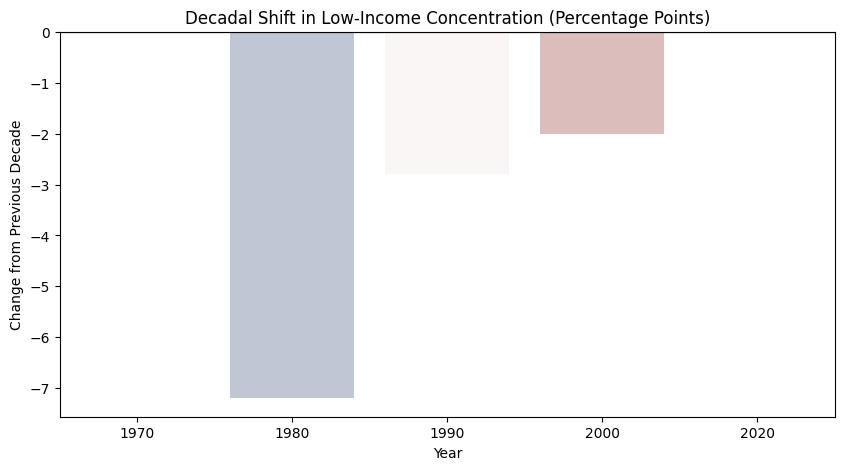

In [9]:
# Calculate decade-over-decade change
df_eda = df_trends.copy()
df_eda['Pop_Growth_Rate'] = df_eda['Total_Pop'].pct_change() * 100
df_eda['Income_Shift'] = df_eda['Low_Inc_%'].diff()

print("Decadal Change Analysis:")
print(df_eda[['Year', 'Pop_Growth_Rate', 'Income_Shift']])

# Plotting the shifts
plt.figure(figsize=(10, 5))
sns.barplot(data=df_eda, x='Year', y='Income_Shift', palette='vlag')
plt.title("Decadal Shift in Low-Income Concentration (Percentage Points)")
plt.ylabel("Change from Previous Decade")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

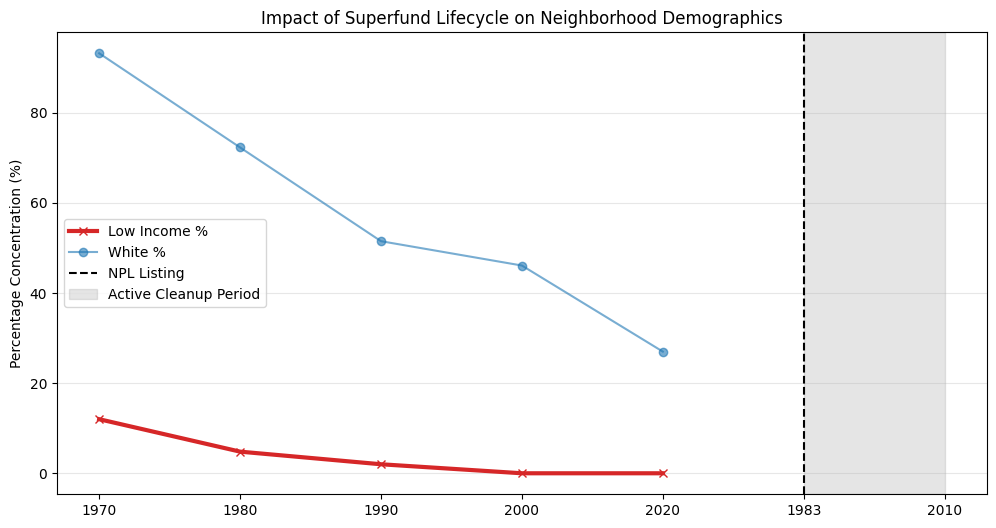

In [10]:
#  ADD SITE MILESTONES 
# Replace these with the actual years
npl_listing_year = 1983  
cleanup_finish_year = 2010 

#  PLOT DEMOGRAPHICS WITH SITE EVENTS 
plt.figure(figsize=(12, 6))

# Plot the Low Income trend calculated earlier
plt.plot(df_trends['Year'], df_trends['Low_Inc_%'], label='Low Income %', marker='x', color='tab:red', linewidth=3)
plt.plot(df_trends['Year'], df_trends['White_%'], label='White %', marker='o', color='tab:blue', alpha=0.6)

# Add Vertical Lines for Superfund Events
plt.axvline(x=str(npl_listing_year), color='black', linestyle='--', label='NPL Listing')
plt.axvspan(str(npl_listing_year), str(cleanup_finish_year), color='gray', alpha=0.2, label='Active Cleanup Period')

plt.title("Impact of Superfund Lifecycle on Neighborhood Demographics")
plt.ylabel("Percentage Concentration (%)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


In [11]:
import geopandas as gpd
import pandas as pd
import os

# --- PATHS ---
gdb_path = r"C:\Users\bays0022\Documents\ArcGIS\Projects\CA_Superfund\CA_Superfund.gdb"
layer_name = "Superfund_table"
tracts_dir = r"C:\Users\bays0022\Desktop\GIS_Data\Census\LA_County_Subsets\Superfund_Buffer_Analysis"

# Load the Superfund Sites
try:
    sf_sites = gpd.read_file(gdb_path, layer=layer_name)
    print("Superfund Table Loaded. Columns:", sf_sites.columns.tolist())
except Exception as e:
    print(f" Error loading GDB table: {e}")

Superfund Table Loaded. Columns: ['PRIMARY_NAME', 'Join_Count', 'TARGET_FID', 'REGISTRY_ID', 'LOCATION_ADDRESS', 'CITY_NAME', 'COUNTY_NAME', 'FIPS_CODE', 'STATE_CODE', 'POSTAL_CODE', 'LATITUDE83', 'LONGITUDE83', 'HUC8_CODE', 'CREATE_DATE', 'UPDATE_DATE', 'PGM_SYS_ID', 'PGM_SYS_ACRNM', 'INTEREST_TYPE', 'PROGRAM_URL', 'PUBLIC_IND', 'ACTIVE_STATUS', 'EPA_REGION_CODE', 'KEY_FIELD', 'COUNTY_NAME_1', 'COUNTY_ABBREV', 'COUNTY_NUM', 'COUNTY_CODE', 'COUNTY_FIPS', 'Risk_1', 'Risk_2', 'Industry']


In [12]:
import geopandas as gpd
import pandas as pd
import os

# --- PATHS ---
gdb_path = r"C:\Users\bays0022\Documents\ArcGIS\Projects\CA_Superfund\CA_Superfund.gdb"
layer_name = "Superfund_table"
tracts_path = r"C:\Users\bays0022\Desktop\GIS_Data\Census\LA_County_Subsets\Superfund_Buffer_Analysis\LA_Final_Merged_tract_2020_Superfund_Buffer.shp"

#  Load Data
latest_tracts = gpd.read_file(tracts_path)
sf_df = gpd.read_file(gdb_path, layer=layer_name)

# Convert Table to Spatial Points using your specific columns
# We use EPSG:4269 because that is the code for NAD83
sf_sites = gpd.GeoDataFrame(
    sf_df, 
    geometry=gpd.points_from_xy(sf_df['LONGITUDE83'], sf_df['LATITUDE83']),
    crs="EPSG:4269" 
).to_crs(latest_tracts.crs) # Project to match your tracts

# SPATIAL JOIN
# This creates a new dataset where every tract knows which Superfund site is inside it
joined = gpd.sjoin(latest_tracts, sf_sites, how="inner", predicate="intersects")

print(f"Success! Joined {len(joined)} tracts to Superfund sites.")

# VIEW THE EJ PROFILE
# Poverty (Low_Inc_20) and Risk level for each site
# Using 'PRIMARY_NAME' from column list
if 'PRIMARY_NAME' in joined.columns:
    summary = joined.groupby('PRIMARY_NAME').agg({
        'Low_Inc_20': 'mean',
        'Black_20': 'mean',
        'Risk_1': 'first', # Pulling the Risk info from your table
        'Industry': 'first'
    }).sort_values('Low_Inc_20', ascending=False)
    
    print("\n--- Top 10 Sites by Surrounding Poverty Concentration ---")
    print(summary.head(10))

Success! Joined 18 tracts to Superfund sites.


KeyError: "Label(s) ['Low_Inc_20'] do not exist"

In [15]:
import pandas as pd

# Clean up the joined data: Force numeric types for the stats
joined['TotPop_20'] = pd.to_numeric(joined['TotPop_20'], errors='coerce')
joined['Black_20'] = pd.to_numeric(joined['Black_20'], errors='coerce')
joined['White_20'] = pd.to_numeric(joined['White_20'], errors='coerce')

# Calculate percentages for the tracts
# We use the 'weight' to ensure we only count the population inside the buffer
joined['Weighted_Pop'] = joined['TotPop_20'] * joined['weight']
joined['Black_Pct'] = (joined['Black_20'] / joined['TotPop_20']) * 100

# Group by Site Name and Industry
# This shows which industries are located in high-density or minority areas
site_summary = joined.groupby(['PRIMARY_NAME', 'Industry']).agg({
    'Weighted_Pop': 'sum',
    'Black_Pct': 'mean',
    'Risk_1': 'first'
}).sort_values('Black_Pct', ascending=False)

print("Top Superfund Sites by Surrounding Minority Concentration (2020):")
print(site_summary.head(15))

Top Superfund Sites by Surrounding Minority Concentration (2020):
                                                Weighted_Pop  Black_Pct  \
PRIMARY_NAME                     Industry                                 
JET PROPULSION LABORATORY (NASA) Government       500.654526  28.786453   
DEL AMO                          Oil             4790.163644  12.648716   
MONTROSE CHEMICAL CORP.          Chemical        4790.163644  12.648716   
EXIDE TECHNOLOGIES               Recycling         89.537947   9.009009   
SAN GABRIEL VALLEY (AREA 1)      Multiple PRP    4457.215354   8.823529   
COOPER DRUM CO.                  Recycling       3982.740102   4.870366   
SOUTHERN AVENUE INDUSTRIAL AREA  Manufacturing   3982.740102   4.870366   
JERVIS B. WEBB CO.               Manufacturing   3982.740102   4.870366   
WASTE DISPOSAL, INC.             Oil             3108.094985   4.835282   
SAN GABRIEL VALLEY (AREA 3)      Multiple PRP    4380.000000   2.762557   
PEMACO MAYWOOD                   C

In [16]:
import os
import pandas as pd
import geopandas as gpd
import re

# --- SETTINGS ---
tracts_dir = r"C:\Users\bays0022\Desktop\GIS_Data\Census\LA_County_Subsets\Superfund_Buffer_Analysis"
all_years_data = []

print(" Retracing the history of each Superfund site...")

for f in sorted(os.listdir(tracts_dir)):
    if f.endswith(".shp"):
        # Load the decade's data
        gdf = gpd.read_file(os.path.join(tracts_dir, f))
        year_full = re.search(r'\d{4}', f).group(0)
        yr = year_full[-2:] 
        
        #  Re-Join to the Superfund Sites
        # sf_sites was created in our previous step from the GDB
        temp_joined = gpd.sjoin(gdf, sf_sites, how="inner", predicate="intersects")
        
        #  Calculate Weighted Stats for that Decade
        # (Using the column naming logic from your previous results)
        pop_col = f'TotPop_{yr}'
        blk_col = f'Black_{yr}'
        
        if pop_col in temp_joined.columns:
            # Ensure numeric
            temp_joined[pop_col] = pd.to_numeric(temp_joined[pop_col], errors='coerce').fillna(0)
            temp_joined[blk_col] = pd.to_numeric(temp_joined[blk_col], errors='coerce').fillna(0)
            
            # Group by site to get the total profile for that year
            stats = temp_joined.groupby('PRIMARY_NAME').agg({
                pop_col: lambda x: (x * temp_joined.loc[x.index, 'weight']).sum(),
                blk_col: lambda x: (x * temp_joined.loc[x.index, 'weight']).sum()
            }).reset_index()
            
            # Formatting
            stats['Year'] = year_full
            stats['Weighted_Pop'] = stats[pop_col].round(0)
            stats['Black_Pct'] = (stats[blk_col] / stats[pop_col] * 100).round(1)
            
            all_years_data.append(stats[['PRIMARY_NAME', 'Year', 'Weighted_Pop', 'Black_Pct']])

#  Final Master Table
df_history = pd.concat(all_years_data)
print(" Timeline complete.")

 Retracing the history of each Superfund site...
 Timeline complete.


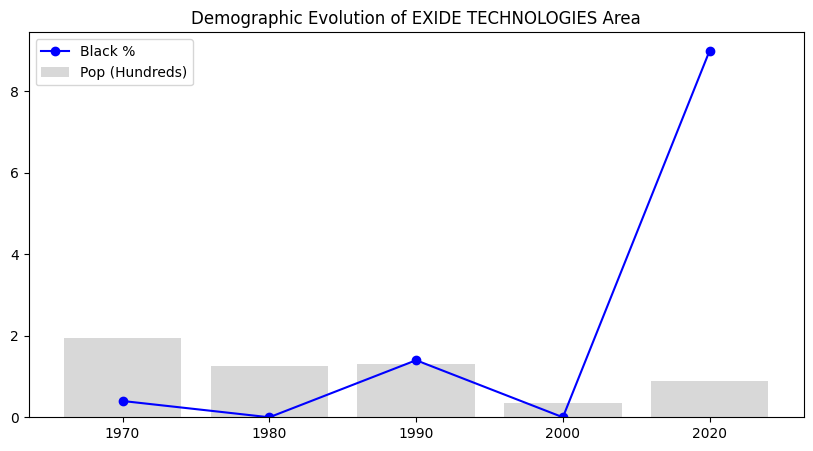

In [17]:
# Change this name to any site from PRIMARY_NAME list
target_site = "EXIDE TECHNOLOGIES" 

site_bio = df_history[df_history['PRIMARY_NAME'] == target_site].sort_values('Year')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(site_bio['Year'], site_bio['Black_Pct'], marker='o', label='Black %', color='blue')
plt.bar(site_bio['Year'], site_bio['Weighted_Pop'] / 100, alpha=0.3, label='Pop (Hundreds)', color='gray')
plt.title(f"Demographic Evolution of {target_site} Area")
plt.legend()
plt.show()

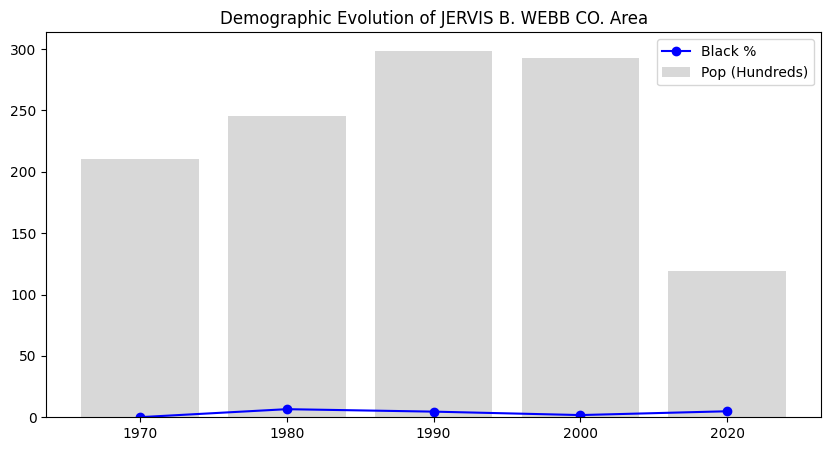

In [18]:
# Change this name to any site from PRIMARY_NAME list
target_site = "JERVIS B. WEBB CO." 

site_bio = df_history[df_history['PRIMARY_NAME'] == target_site].sort_values('Year')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(site_bio['Year'], site_bio['Black_Pct'], marker='o', label='Black %', color='blue')
plt.bar(site_bio['Year'], site_bio['Weighted_Pop'] / 100, alpha=0.3, label='Pop (Hundreds)', color='gray')
plt.title(f"Demographic Evolution of {target_site} Area")
plt.legend()
plt.show()

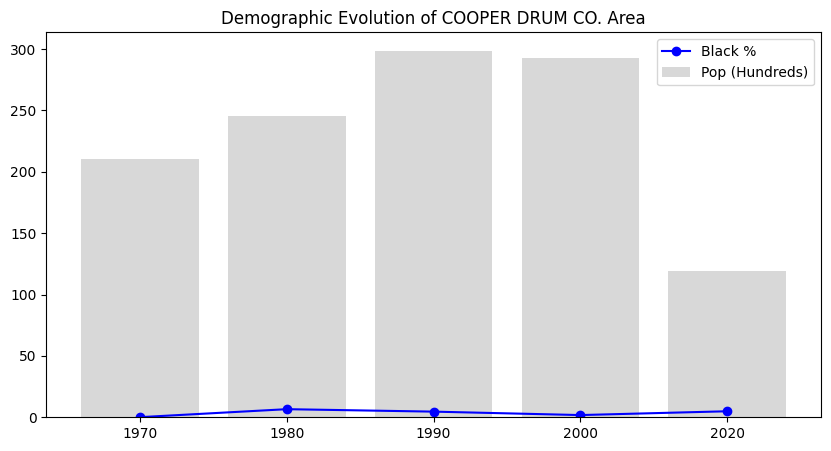

In [19]:
# Change this name to any site from PRIMARY_NAME list
target_site = "COOPER DRUM CO." 

site_bio = df_history[df_history['PRIMARY_NAME'] == target_site].sort_values('Year')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(site_bio['Year'], site_bio['Black_Pct'], marker='o', label='Black %', color='blue')
plt.bar(site_bio['Year'], site_bio['Weighted_Pop'] / 100, alpha=0.3, label='Pop (Hundreds)', color='gray')
plt.title(f"Demographic Evolution of {target_site} Area")
plt.legend()
plt.show()

In [49]:
import os
import pandas as pd
import geopandas as gpd
import re

# --- PATHS ---
tracts_dir = r"C:\Users\bays0022\Desktop\GIS_Data\Census\LA_County_Subsets\Superfund_Buffer_Analysis"
gdb_path = r"C:\Users\bays0022\Documents\ArcGIS\Projects\CA_Superfund\CA_Superfund.gdb"
layer_name = "Superfund_table"
output_csv = r"C:\Users\bays0022\Documents\ArcGIS\Projects\CA_Superfund\Master_Demographics_FINAL.csv"

# Load Superfund Table
sf_df = gpd.read_file(gdb_path, layer=layer_name)
sf_sites = gpd.GeoDataFrame(
    sf_df, 
    geometry=gpd.points_from_xy(sf_df['LONGITUDE83'], sf_df['LATITUDE83']),
    crs="EPSG:4269" 
)

master_data = []

print(" Starting Global Site Analysis...")

# Iterate through every Census Year
for f in sorted(os.listdir(tracts_dir)):
    if f.endswith(".shp"):
        year_full = re.search(r'\d{4}', f).group(0)
        yr = year_full[-2:] 
        
        print(f"--- Processing {year_full} ---")
        gdf = gpd.read_file(os.path.join(tracts_dir, f))
        
        # Ensure CRS Match
        if sf_sites.crs != gdf.crs:
            sf_sites = sf_sites.to_crs(gdf.crs)
            
        # Spatial Join
        joined = gpd.sjoin(gdf, sf_sites, how="inner", predicate="intersects")
        
        # Handle Column Names and Numeric Types
        pop_col = f'TotPop_{yr}'
        blk_col = f'Black_{yr}'
        wht_col = f'White_{yr}'
        
        # Force numeric conversion to prevent the multiplication error
        for col in [pop_col, blk_col, wht_col, 'weight']:
            if col in joined.columns:
                joined[col] = pd.to_numeric(joined[col], errors='coerce').fillna(0)
        
        #  Group and Calculate
        if not joined.empty:
            for site_name, site_group in joined.groupby('PRIMARY_NAME'):
                total_pop = (site_group[pop_col] * site_group['weight']).sum()
                black_pop = (site_group[blk_col] * site_group['weight']).sum()
                
                master_data.append({
                    'Site_Name': site_name,
                    'Year': year_full,
                    'Estimated_Pop': round(total_pop, 0),
                    'Black_Percent': round((black_pop / total_pop * 100), 2) if total_pop > 0 else 0
                })

#  Create DataFrame and Save
if master_data:
    df_master = pd.DataFrame(master_data)
    df_master.to_csv(output_csv, index=False)
    print(f"\n SUCCESS! File saved to: {output_csv}")
    print(df_master.head(10))
else:
    print(" No data was generated. Check if your Superfund points overlap your tracts.")

 Starting Global Site Analysis...
--- Processing 1970 ---
--- Processing 1980 ---
--- Processing 1990 ---
--- Processing 2000 ---
--- Processing 2020 ---

 SUCCESS! File saved to: C:\Users\bays0022\Documents\ArcGIS\Projects\CA_Superfund\Master_Demographics_FINAL.csv
                          Site_Name  Year  Estimated_Pop  Black_Percent
0                   COOPER DRUM CO.  1970         7019.0           0.05
1                           DEL AMO  1970          142.0           2.11
2                EXIDE TECHNOLOGIES  1970          195.0           0.38
3                JERVIS B. WEBB CO.  1970         7019.0           0.05
4  JET PROPULSION LABORATORY (NASA)  1970          353.0          50.33
5           MONTROSE CHEMICAL CORP.  1970          142.0           2.11
6              OMEGA CHEMICAL CORP.  1970         9849.0           0.10
7              OPERATING INDUSTRIES  1970         3035.0           0.02
8                    PEMACO MAYWOOD  1970         1533.0           0.07
9      SAN FE

In [ ]:
import pandas as pd
import folium
from IPython.display import display

#  Load Data
file_path = r"C:\Users\bays0022\Desktop\GIS_Data\LA\superfund.xls"
df = pd.read_excel(file_path, engine='xlrd')
df_clean = df.dropna(subset=['LATITUDE83', 'LONGITUDE83'])

#  Build Map with "CartoDB Positron" tiles (More reliable than OpenStreetMap)
# prefer_canvas=True helps with rendering issues in VS Code/Jupyter
m = folium.Map(
    location=[34.05, -118.24], 
    zoom_start=10, 
    tiles='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png',
    attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
    prefer_canvas=True
)

# Add Markers
for _, row in df_clean.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE83'], row['LONGITUDE83']],
        radius=6,
        color='red',
        fill=True,
        fill_opacity=0.7,
        popup=row['PRIMARY_NAME']
    ).add_to(m)

# Display
display(m)